In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import coulomb as cb
    
pressure_list = (1.5,2,2.25,2.5)

exp_data = {p: pd.read_csv(f'../data/gass_et_al_2024/gass_et_al_data_{p*1e3:.0f}.csv',skiprows=1).iloc[::4] 
            for p in pressure_list}

In [8]:
def compute_ui_curve(current_density, fuel_cell, stack_pressure): 
   
    stack_temperature = 74.15 + 273.15
    cathode_conditions = cb.OperatingConditions(
        inlet_temperature = stack_temperature,
        inlet_relative_humidity=.6,
        outlet_pressure=stack_pressure,
        dry_o2_mole_fraction=0.21,
        dry_h2_mole_fraction=0,
        stoichiometry=np.maximum(2., 2 * 0.1e4 / (current_density+1e-4))
    )
    anode_conditions = cb.OperatingConditions(
        inlet_temperature = stack_temperature,
        inlet_relative_humidity=0.4,
        dry_h2_mole_fraction=1, 
    dry_o2_mole_fraction=0,
    outlet_pressure=stack_pressure,
    stoichiometry=np.maximum(1.2, 1.2 * 0.1e4 / (current_density+1e-4))
    )

    fuel_cell.set_conditions(stack_temperature, current_density,cathode_conditions, anode_conditions)
    fuel_cell.calculate_heat_transfer_resistance()
    mea_temperature = fuel_cell.temperature + (fuel_cell.current_density * 0.7) * fuel_cell.thermal_resistance
    fuel_cell.set_mea_temperature(mea_temperature)
    fuel_cell.calculate_water_transport()
    fuel_cell.calculate_reactant_concentration_at_cl()


    # dT = 0
    # for i in range(5): 
    #     mea_temperature = fuel_cell.temperature + dT
    #     fuel_cell.set_mea_temperature(mea_temperature)
    #     fuel_cell.calculate_water_transport()
    #     fuel_cell.calculate_reactant_concentration_at_cl()
    #     V_cell = fuel_cell.cell_voltage()
    #     dT = fuel_cell.current_density * (1.4 * fuel_cell.ca.liquid_flux_ratio + 1.2 * (1-fuel_cell.ca.liquid_flux_ratio) - V_cell) * fuel_cell.ca.gdl.thickness / fuel_cell.dT_ref

    #fuel_cell.solve_transport() 
    return fuel_cell.cell_voltage()

In [9]:
def create_fuel_cell(params): 
    fc = cb.FuelCell(
        electrical_resistance=params['elec-resistance'],
        cell_area = 85e-4, 
        cell_number = 1, 
        ca = cb.FuelCellSide(
            cl=cb.CatalystLayer(
                ecsa=params['ECSA'], 
                platinum_loading=0.4e-2, 
                ionomer=cb.CatalystLayerIonomerModel(
                    hydrated_proton_conductivity=params['S-cl-0'], 
                    proton_conductivity_rh_exponent=0,
                    proton_conductivity_water_content_exponent=params['R-cl-exponent'],
                    o2_diffusion_exponent=params['o2-diff-exponent'],
                ),
                ionomer_vol_fraction=params['ionomer-vol-fraction'],
                porosity=0.4,
                pore_diameter=80e-9,
                omega_PtO=0, 
                effective_gas_diffusion_ratio=10000.,
                ionomer_film_thickness=params['ionomer-thickness'],
                thickness=params['ca-cl-thickness'],
                thermal_conductivity=0.25,
                reaction=cb.ElectrochemicalReaction(
                    reference_exchange_current_density=2.5e-4, 
                    reaction_order=0.54, 
                    activation_energy=67e6, 
                    reference_activity=1.01325e5,
                    reference_temperature=353.15,
                    number_of_electrons=2,
                    charge_transfer_coeff=0.5
                ), 
                
            ),
            gdl=cb.PorousLayer(
                thickness=200e-6,
                effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
                absolute_permeability=params['Kabs'],
                thermal_conductivity=params['gdl-deltaT-ref'] 
            ),
            has_mpl=False, 
            ch=cb.GasFlowChannel(
                reactant='o2',
                transport_resistance_model = cb.ChannelGasResistanceModel(A_ch=params['A_ch'], B_ch=params['B_ch'])
            ),
            liq_transport_model=cb.DarcyLiquidTransportModel(
                dry_wet_transition_parameter=params['wet-transition']
            ),
            thermal_contact_resistance=2e-4,
        ),
        an = cb.FuelCellSide(
            cl=cb.CatalystLayer(
                thickness=6e-6, 
                effective_gas_diffusion_ratio=100000.,
                ionomer_vol_fraction=params['ionomer-vol-fraction'],
                porosity=0.4,
                thermal_conductivity=0.25,
                pore_diameter=80e-9
            ),
            has_mpl=False, 
            gdl=cb.PorousLayer(
                thickness=200e-6,
                effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
                thermal_conductivity=params['gdl-deltaT-ref'] 
            ),
            ch=cb.GasFlowChannel(
                reactant='h2',
                transport_resistance_model = cb.ChannelGasResistanceModel(A_ch=params['A_ch'],B_ch=params['B_ch'])
            ),
            thermal_contact_resistance=2e-4,
        ),
        membrane = cb.Membrane(
            equivalent_weight=1000,
            density=2000, 
            dry_thickness=params['memb-thickness'],
            conductivity_exp=params['memb-cond-exp'],
            conductivity_correction=params['memb-cond-correction'],
            h2_permeation_model=cb.HydrogenPermeationModel(), 
            water_balance_model=cb.MembraneWaterBalanceModel(reference_absorption_coefficient=params['memb-abs-constant'])
        )
    )
    fc.dT_ref = params['gdl-deltaT-ref']
    # for side in (fc.ca, fc.an):
    #     side.ch.transport_resistance_model.B_ch = fc.cell_area / (side.ch.length /side.ch.half_width * side.ch.total_flow_section)/ 2
    return fc

None


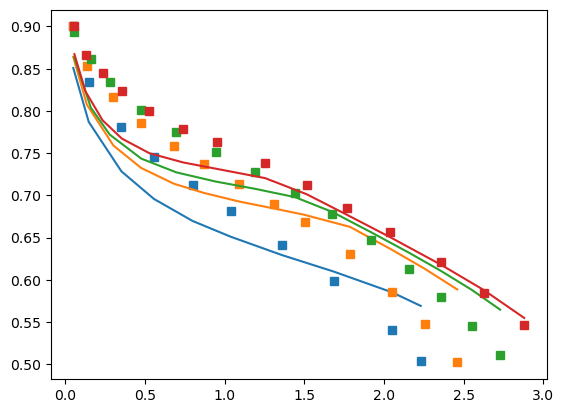

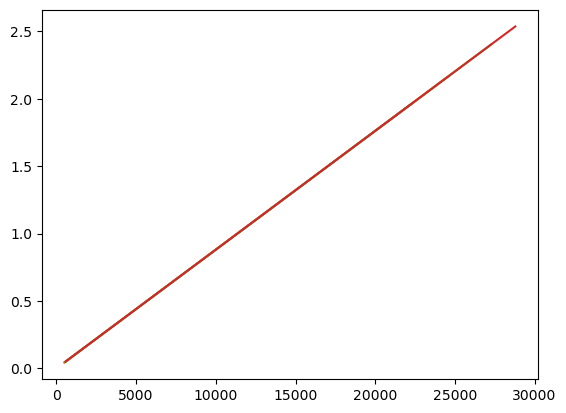

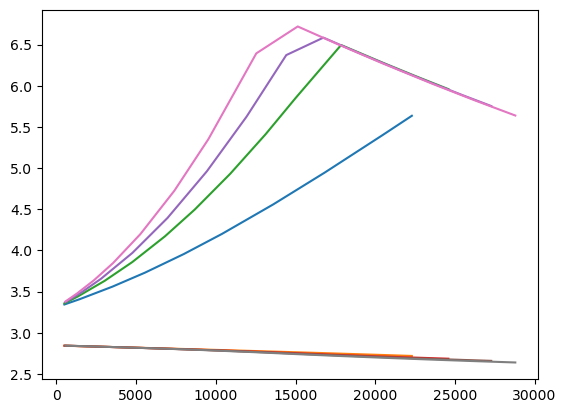

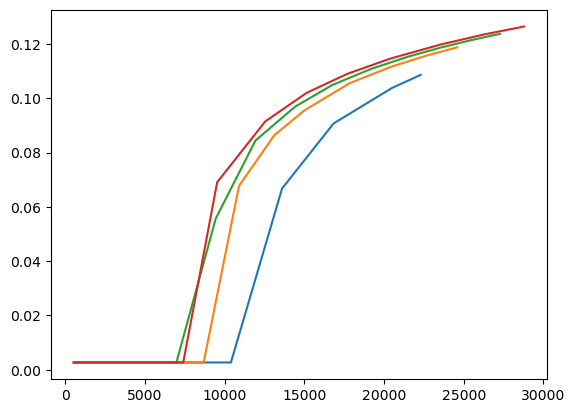

In [10]:
def h(params): 
    fuel_cell = create_fuel_cell(params)
    return np.concatenate(
         [compute_ui_curve(exp_data[p]['i'].values*1e4, fuel_cell, p*1e5)
          for p in pressure_list]
    )

exp_voltage_list = np.concatenate(
         [exp_data[p]['U'] for p in pressure_list]
    )

model = cb.ParameterEstimationSteadyState(h, {'ECSA': 80e3,                 
                                              'elec-resistance': 40e-7,
                                              'gdl-eff-diff-ratio': 0.2,
                                              'memb-abs-constant': 1e-5, 
                                              'ionomer-thickness': 4.14e-8,
                                              'ionomer-vol-fraction':0.3,
                                              'ca-cl-thickness': 1e-5,
                                              'S-cl-0': 17.5,
                                              'A_ch': 0, 
                                              'B_ch': 0, 
                                              'R-cl-exponent': 3.82, # Voir Eskandari 2022
                                              'wet-transition': 0.2,
                                              'memb-thickness': 20e-6,
                                              'memb-cond-exp':1.0,
                                              'memb-cond-correction': 1, 
                                              'gdl-deltaT-ref': 10,
                                              'o2-diff-exponent': .708,
                                              'Kabs':1.e-13, 
                                              'omega-PtO': 0})

fuel_cell = create_fuel_cell(model.p)
print(fuel_cell.calculate_heat_transfer_resistance())
for k, p in enumerate(pressure_list): 
    U_sim = compute_ui_curve(exp_data[p]['i'].values*1e4, fuel_cell, p*1e5)
    plt.figure(1)
    plt.plot(exp_data[p]['i'].values, U_sim, 'C{}-'.format(k))
    plt.plot(exp_data[p]['i'].values, exp_data[p]['U'].values, 'C{}s'.format(k))
    plt.figure(2)
    plt.plot(fuel_cell.current_density, fuel_cell.mea_temperature_increase)
    plt.figure(3)
    
    plt.plot(fuel_cell.current_density,fuel_cell.membrane.water_content)
    plt.plot(fuel_cell.current_density,fuel_cell.an.cl.water_content)
    # # plt.ylim([0,14])


        #plt.plot(fuel_cell.current_density, fuel_cell.ca.equiv_water_content, 'C{}-.'.format(k))
   
    plt.figure(4)
    plt.plot(fuel_cell.current_density, fuel_cell.ca.gdl.water_saturation)


In [11]:
model.set_unknown_params(
        [
        #('memb-thickness', (5e-6, 30e-6), True, '$t_m$'), 
        #('o2-diff-exponent', (0.5,2), True, '$m_{o2}$'),
        # ('memb-cond-exp', (1,2), True, '$m_{o2}$'),
        #('memb-cond-correction',(.1,2), True, 'k_cond'),
        ('elec-resistance', (20e-7,60e-7), True, '$R_{elec}$'),
        #('ECSA', (30e3,100e3), False, '$ECSA$'),
        #('alpha-ca', (0.4, 1), True, 'alpha-ca'),
        # ('pt-loading', (0.2e-2, 0.4e-2), True, 'Pt load'),
        # ('pt-wt', (0.3,0.4), True, 'Pt wt'),
        # ('ic-ratio', (0.7,1.0), True, 'IC ratio'),
        #('gamma-c', (0.5,2), True, '$\gamma_c$'),
        #('ca-cl-thickness', (6e-6, 15e-6), True, '$t_{cl}$'),
        #('crossover-current', (0,2), True, '$i_x$'), 
        ('gdl-eff-diff-ratio', (0.1,0.4), True, '$t_{\mathrm{O}_2,eq}$'), 
        ('ionomer-thickness', (1.e-9,80.e-9), True, '$t_{ion}$'),
        #('A_ch', (1e-8, 10), False, '$A_{ch}$'),
        ('B_ch', (0, 5), True, '$B_{ch}$'),
        #('ionomer-vol-fraction', (0.15,0.4), True, r'$\varepsilon_{ion}$'),
        #('Kabs', (1e-14,1e-10), False, '$K_{l}$'),
        #('wet-saturation', (0.1,0.5), True, '$s_{wet}$'),
        #('wet-transition', (0, .5), True, '$alpha_{wet}$'),
        #('critical-damkholer', (0.8,2), True, '$Da_{w,cr}$'),
        ('gdl-deltaT-ref', (0.1,4), True, '$k_{GDL}$'),
        #('R-ch-correction', (0.,1.), True, '$R_{ch}$'),
        ('R-cl-exponent', (1, 5), True, '$m_{R_{cl}}$'),
        ('S-cl-0', (1,200), False, '$R_{cl,0}$'),
        #('ionomer-vol-fraction', (0.1,.5), True, '$\epsilon_{ion}$'),
        #('E-act-ca', (50e3, 100e3), True, '$E_{act, ca}$'),
        #('omega-PtO', (1e6, 10e6), True, '$\omega_{PtO}$'),
        #('memb-water-diff', (1e-10, 40e-10), True, '$D_{\lambda}$'),
        #('memb-abs-constant', (1e-6, 10e-5), True, '$k_{abs}$'),
        ]
    )


In [12]:

cosPhi_med_ij, norm_s_i, S_med, S_std, S_med_i, S_std_i, S_n, n_valid = model.compute_global_sensitivity(t=0, m=6,  
                                                                                                         check_samples=True,
                                                                                                         y_exp=exp_voltage_list, 
                                                                                                         res_limit=0.02)


Number of valid samples: 18


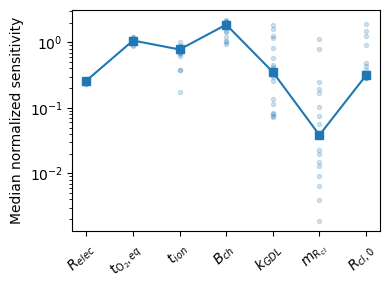

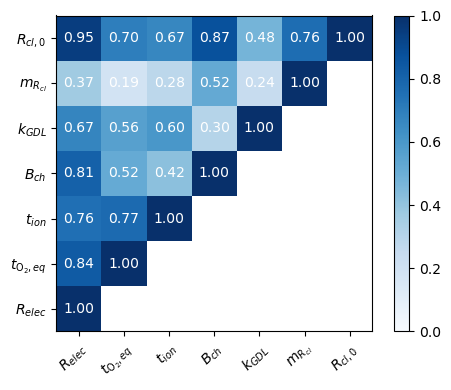

In [13]:
print('Number of valid samples: {:d}'.format(n_valid))
fig1, ax1 = model.plot_global_sensitivity(xlabel_angle=45) 
fig2, ax2 = model.plot_colinearity_map(xlabel_angle=45, cmap='Blues',figsize=(5,4))

plt.show()

In [14]:
sol, p_est = model.estimate(exp_voltage_list, t=0, print_iterations=True, popsize=20, ftol=1e-5)
model.p.update({param: v for param, v in zip(model.p_i_name, p_est)})

differential_evolution step 1: f(x)= 0.0003419208084178227
------------------------------
RMSE : 18.5 mV
elec-resistance (2e-06, 6e-06) 3.99e-06
gdl-eff-diff-ratio (0.1, 0.4) 3.97e-01
ionomer-thickness (1e-09, 8e-08) 4.17e-08
B_ch (0, 5) 3.85e-01
gdl-deltaT-ref (0.1, 4) 3.10e-01
R-cl-exponent (1, 5) 1.49e+00
S-cl-0 (1, 200) 1.21e+01
------------------------------
differential_evolution step 2: f(x)= 0.00012404458022862404
------------------------------
RMSE : 11.1 mV
elec-resistance (2e-06, 6e-06) 3.50e-06
gdl-eff-diff-ratio (0.1, 0.4) 3.98e-01
ionomer-thickness (1e-09, 8e-08) 7.49e-09
B_ch (0, 5) 9.29e-01
gdl-deltaT-ref (0.1, 4) 1.45e-01
R-cl-exponent (1, 5) 2.53e+00
S-cl-0 (1, 200) 1.75e+01
------------------------------
differential_evolution step 3: f(x)= 0.00012404458022862404
------------------------------
RMSE : 11.1 mV
elec-resistance (2e-06, 6e-06) 3.50e-06
gdl-eff-diff-ratio (0.1, 0.4) 3.98e-01
ionomer-thickness (1e-09, 8e-08) 7.49e-09
B_ch (0, 5) 9.29e-01
gdl-deltaT-ref (0.1

In [15]:
''''
------------------------------
differential_evolution step 89: f(x)= 4.8828914294235896e-05
------------------------------
RMSE : 7.0 mV
memb-thickness (5e-06, 3e-05) 2.67e-05
memb-cond-exp (1, 2) 1.06e+00
memb-cond-correction (0.1, 2) 7.12e-01
ca-cl-thickness (6e-06, 1.5e-05) 6.96e-06
gdl-eff-diff-ratio (0.1, 0.4) 4.00e-01
A_ch (1e-08, 10) 2.65e-04
B_ch (0, 5) 5.78e-01
Kabs (1e-14, 1e-10) 7.20e-13
wet-transition (0, 0.5) 1.01e-01
gdl-deltaT-ref (0.01, 4) 3.31e-01
R-cl-exponent (1, 5) 2.02e+00
S-cl-0 (1, 200) 3.62e+01
memb-abs-constant (1e-06, 0.0001) 2.87e-06
------------------------------
'''

"'\n------------------------------\ndifferential_evolution step 89: f(x)= 4.8828914294235896e-05\n------------------------------\nRMSE : 7.0 mV\nmemb-thickness (5e-06, 3e-05) 2.67e-05\nmemb-cond-exp (1, 2) 1.06e+00\nmemb-cond-correction (0.1, 2) 7.12e-01\nca-cl-thickness (6e-06, 1.5e-05) 6.96e-06\ngdl-eff-diff-ratio (0.1, 0.4) 4.00e-01\nA_ch (1e-08, 10) 2.65e-04\nB_ch (0, 5) 5.78e-01\nKabs (1e-14, 1e-10) 7.20e-13\nwet-transition (0, 0.5) 1.01e-01\ngdl-deltaT-ref (0.01, 4) 3.31e-01\nR-cl-exponent (1, 5) 2.02e+00\nS-cl-0 (1, 200) 3.62e+01\nmemb-abs-constant (1e-06, 0.0001) 2.87e-06\n------------------------------\n"

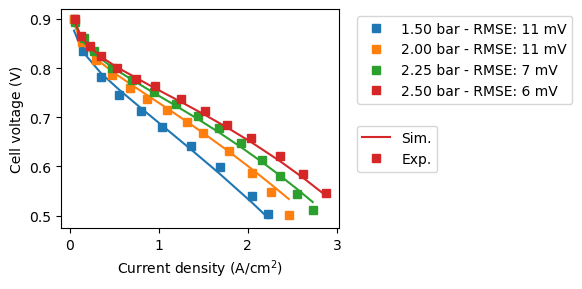

In [16]:
fuel_cell = create_fuel_cell(model.p)
fig, ax = plt.subplots(figsize=(6,3))
fig.set_tight_layout(True)
RMSE_avg = 0
for k, p in enumerate(pressure_list): 
    i_exp = exp_data[p]['i'].values
    U_exp = exp_data[p]['U'].values
    U_sim = compute_ui_curve(i_exp*1e4, fuel_cell, p*1e5)
    res = U_exp - U_sim
    RMSE = np.sqrt(np.dot(res, res) / len(res)) * 1000
    RMSE_avg += RMSE
    l1, = ax.plot(i_exp, U_sim, '-C{}'.format(k))
    l2, = ax.plot(i_exp, U_exp, 'sC{}'.format(k), label='{:.2f} bar - RMSE: {:.0f} mV'.format(p, RMSE))
leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.add_artist(leg2)
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Cell voltage (V)')
fig.tight_layout()

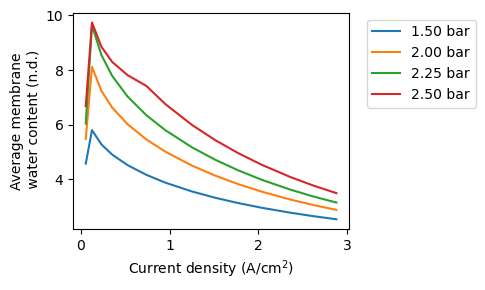

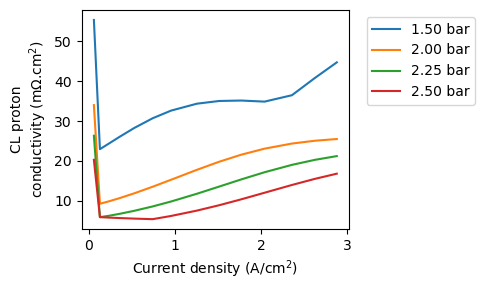

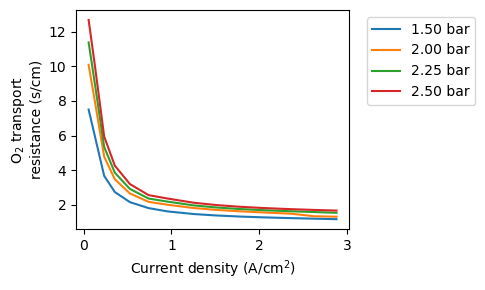

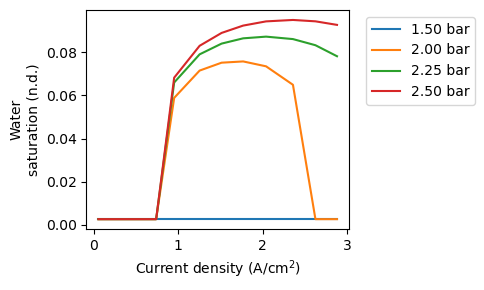

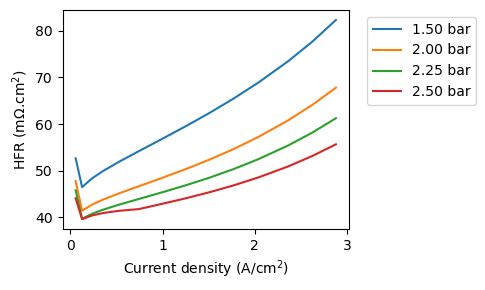

In [17]:

fuel_cell = create_fuel_cell(model.p)
fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(pressure_list): 
   U_sim = compute_ui_curve(i_exp*1e4, fuel_cell, p*1e5)
   ax.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.water_content, label='{:.2f} bar'.format(p, RMSE))
   # ax.plot(fuel_cell.current_density/1e4, fuel_cell.ca.membrane_surface_water_content, '--', label='{:.2f} bar'.format(p, RMSE))
   # ax.plot(fuel_cell.current_density/1e4, fuel_cell.ca.equiv_water_content, '.-', label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Average membrane\n water content (n.d.)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(pressure_list): 
   U_sim = compute_ui_curve(i_exp*1e4, fuel_cell, p*1e5)
   ax.plot(fuel_cell.current_density/1e4, 1e7*fuel_cell.ca.cl.proton_resistance, label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('CL proton\nconductivity (m$\Omega$.cm$^2$)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(pressure_list): 
   U_sim = compute_ui_curve(i_exp*1e4, fuel_cell, p*1e5)
   ax.plot(fuel_cell.current_density/1e4, 1e-2*fuel_cell.ca.o2_transport_resistance, label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('O$_2$ transport\nresistance (s/cm)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(pressure_list): 
   U_sim = compute_ui_curve(i_exp*1e4, fuel_cell, p*1e5)
   ax.plot(fuel_cell.current_density/1e4, fuel_cell.ca.gdl.water_saturation, label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('Water\nsaturation (n.d.)')
fig.tight_layout()

fig, ax = plt.subplots(figsize=(5,3))
fig.set_tight_layout(True)
for k, p in enumerate(pressure_list): 
   U_sim = compute_ui_curve(i_exp*1e4, fuel_cell, p*1e5)
   ax.plot(fuel_cell.current_density/1e4, 1e7*fuel_cell.high_frequency_resistance(), label='{:.2f} bar'.format(p, RMSE))
#leg2 = ax.legend(handles=[l1,l2], labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.04,0.5), loc='upper left') 
leg1 = ax.legend(bbox_to_anchor=(1.04,1), loc='upper left') 
ax.set_xlabel('Current density (A/cm$^2$)')
ax.set_ylabel('HFR (m$\Omega$.cm$^2$)')
fig.tight_layout()


